# GeoBrain Seismic Forward Modeling

From Porosity to Pre-stack Seismic (Angle Gathers).

Workflow:
1. Generate correlated geological properties (porosity, sand volume)
2. Rock physics modeling (VRH, Soft Sand, Gassmann)
3. Compute elastic properties (Vp, Vs, Density)
4. Generate pre-stack synthetic seismic (angle gathers)

---

This notebook builds the complete **pre-stack seismic forward model**:

```
Porosity + Sand volume → Rock physics → (Vp, Vs, ρ)
    → Shuey AVO reflectivity → Wavelet convolution → Angle gathers
```

Three angle stacks (near, mid, far) are generated with angle-dependent
frequency attenuation.

In [1]:
import sys
sys.path.insert(0, '../..')

import os
import torch
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.titleweight': 'semibold',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'legend.framealpha': 0.9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#e0e0e0',
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'image.cmap': 'viridis',
})

FIGS_DIR = os.path.join('..', 'figs')
os.makedirs(FIGS_DIR, exist_ok=True)

from geobrain.geomodel import Simulator, CoSimConfig
from geobrain.data.transforms import sigmoid_transform
from geobrain.vis import plot_field, plot_section
from geobrain.physics.rock import VRH, Gassmann, SoftSand, DensityModel, v_from_moduli
from geobrain.physics.wave import RickerWavelet, create_conv_matrix, compute_reflectivity

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(2025)
print(f"Using device: {device}")

Using device: cpu


## Seismic Parameters

| Parameter | Values | Notes |
|-----------|--------|-------|
| Incidence angles | 12°, 24°, 36° | Near / Mid / Far |
| Wavelet frequencies | 30, 25, 20 Hz | Lower frequency at far angles mimics real data |
| Sample interval | dt = 1 ms | |

In [2]:
# Grid dimensions
NX, NY, NZ = 64, 64, 128

# Property ranges
phi_range = (0.05, 0.4)
vsand_range = (0.2, 0.8)
target_corr = 0.7

# Mineral parameters (quartz and clay)
MINERAL_PARAMS = {
    "Kminc": torch.tensor([36.6, 21.0], device=device),    # Bulk moduli (GPa)
    "Gminc": torch.tensor([44.0, 9.0], device=device),     # Shear moduli (GPa)
    "Rhominc": torch.tensor([2.65, 2.5], device=device),   # Densities (g/cm³)
    "Volminc": torch.tensor([0.9, 0.1], device=device)     # Volume fractions
}

# Fluid parameters (water and gas)
FLUID_PARAMS = {
    "Kflc": torch.tensor([3.06, 0.10], device=device),     # Bulk moduli (GPa)
    "Rhoflc": torch.tensor([1.08, 0.72], device=device),   # Densities (g/cm³)
    "patchy": 0.0                                          # Fluid mixing (0=Reuss, 1=Voigt)
}

# Rock physics settings
EFFECTIVE_PRESSURE = 20      # MPa
CRITICAL_POROSITY = 0.4
COORDINATION_NUMBER = 7

# Seismic parameters
THETA_ANGLES = [12, 24, 36]           # Incident angles (degrees)
WAVELET_FREQS = [30, 25, 20]          # Wavelet frequencies per angle (Hz)
WAVELET_DT = 0.001                    # Time sampling (s)

## Generate Geological Model

Same co-simulation workflow as the rock-physics example: correlated porosity
and sand volume fields via FFT-MA + sigmoid transform.

In [3]:
correlation_matrix = torch.tensor([
    [1.0, target_corr],
    [target_corr, 1.0]
])

config = CoSimConfig(
    shape=(NX, NY, NZ),
    n_variables=2,
    correlation_matrix=correlation_matrix,
    field_names=["phi", "vsand"],
    lh=20,
    lv=5,
    device=str(device),
    seed=2025
)

simulator = Simulator.create('fft_ma')
fields = simulator.simulate(config)

# Transform to physical ranges
stacked = torch.stack([fields["phi"].cpu(), fields["vsand"].cpu()])
transformed = sigmoid_transform(stacked, ranges=[phi_range, vsand_range])

phi = transformed[0].to(device)
vsand = transformed[1].to(device)

print(f"Porosity: range=[{phi.min():.3f}, {phi.max():.3f}]")
print(f"Sand Volume: range=[{vsand.min():.3f}, {vsand.max():.3f}]")

Porosity: range=[0.057, 0.394]
Sand Volume: range=[0.211, 0.791]


## Rock Physics

The VRH → Soft Sand → Gassmann chain converts geological properties into
elastic parameters (Vp, Vs, ρ).  These serve as input to the seismic
reflectivity calculation.

In [4]:
# Initialize models
vrh = VRH()
soft_sand = SoftSand()
gassmann = Gassmann()
density_model = DensityModel()

# Mineral properties (VRH averaging)
vol = MINERAL_PARAMS["Volminc"]
_, _, K_m = vrh(vol, MINERAL_PARAMS["Kminc"])
_, _, G_m = vrh(vol, MINERAL_PARAMS["Gminc"])
rho_m = (MINERAL_PARAMS["Rhominc"] * vol).sum()

print(f"Mineral: K={K_m:.2f} GPa, G={G_m:.2f} GPa, ρ={rho_m:.2f} g/cm³")

# Fluid properties
Sw = torch.ones_like(phi, device=device)  # 100% water saturation
k_w, k_hc = FLUID_PARAMS["Kflc"]
rho_w, rho_hc = FLUID_PARAMS["Rhoflc"]

k_fl = 1.0 / (Sw / k_w + (1 - Sw) / k_hc)  # Reuss average
rho_fl = Sw * rho_w + (1 - Sw) * rho_hc

print(f"Fluid: K={k_fl.mean():.2f} GPa, ρ={rho_fl.mean():.2f} g/cm³")

# Dry frame (Soft Sand model)
press = torch.ones_like(phi, device=device) * EFFECTIVE_PRESSURE
k_dry, g_dry = soft_sand(K_m, G_m, phi, CRITICAL_POROSITY, COORDINATION_NUMBER, press)

# Saturated properties (Gassmann)
k_sat, g_sat = gassmann(k_dry, g_dry, K_m, k_fl, phi)
rho = density_model(phi, rho_m, rho_fl)

print(f"K_sat: range=[{k_sat.min():.2f}, {k_sat.max():.2f}] GPa")
print(f"G_sat: range=[{g_sat.min():.2f}, {g_sat.max():.2f}] GPa")

# Elastic velocities
vp, vs = v_from_moduli(k_sat, g_sat, rho)

print(f"Vp: range=[{vp.min():.2f}, {vp.max():.2f}] km/s")
print(f"Vs: range=[{vs.min():.2f}, {vs.max():.2f}] km/s")
print(f"Density: range=[{rho.min():.2f}, {rho.max():.2f}] g/cm³")

Mineral: K=17.52 GPa, G=20.25 GPa, ρ=2.63 g/cm³
Fluid: K=3.06 GPa, ρ=1.08 g/cm³
K_sat: range=[6.56, 14.46] GPa
G_sat: range=[1.48, 9.56] GPa
Vp: range=[2054.48, 3268.41] km/s
Vs: range=[855.38, 1937.22] km/s
Density: range=[2.02, 2.55] g/cm³


## Seismic Forward Modelling

Two stages:

1. **Angle-dependent reflectivity** via the Shuey two-term AVO
   approximation:
   $$R(\theta) \approx R_0 + G\,\sin^2\theta$$
   where $R_0$ is the zero-offset reflectivity and $G$ is the AVO
   gradient.

2. **Wavelet convolution**: each angle stack uses a Ricker wavelet at the
   corresponding frequency.  The `einsum` operation performs efficient
   batched convolution across all traces.

Generated 3 convolution matrices
Matrix shape: torch.Size([127, 127])


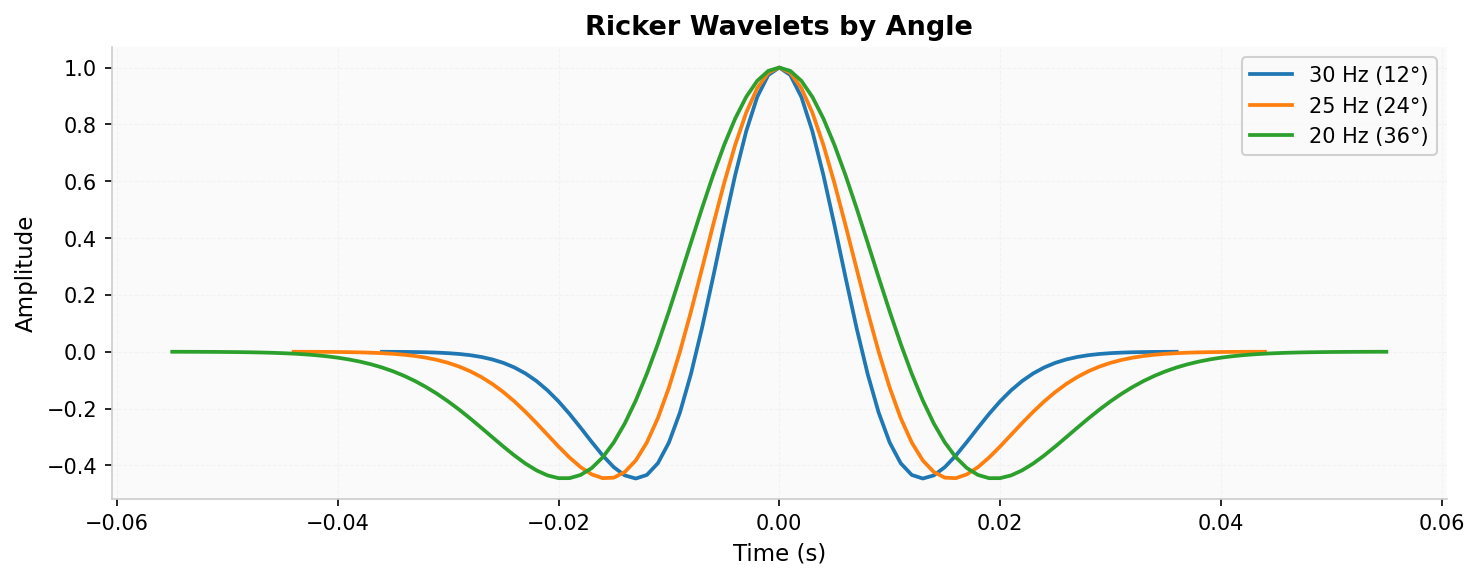

Reflectivity shape: torch.Size([3, 64, 64, 127])  # [n_angles, nx, ny, nz-1]
Reflectivity range: [-0.1861, 0.1636]
Pre-stack seismic shape: torch.Size([3, 64, 64, 127])  # [n_angles, nx, ny, nt]
Amplitude range: [-0.3746, 0.3492]


In [5]:
# -----------------------------------------------------------------------------
# Generate Wavelets
# -----------------------------------------------------------------------------

n_samples = NZ - 1
ricker = RickerWavelet()
conv_matrices = []
for freq in WAVELET_FREQS:
    wavelet, _ = ricker(f0=float(freq), dt=float(WAVELET_DT), device=str(device))
    W = create_conv_matrix(wavelet, n_samples, mode='same').T
    conv_matrices.append(W)

print(f"Generated {len(conv_matrices)} convolution matrices")
print(f"Matrix shape: {conv_matrices[0].shape}")

# Visualize wavelets
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
fig, ax = plt.subplots(figsize=(10, 4))
for i, freq in enumerate(WAVELET_FREQS):
    wavelet, t = ricker(f0=float(freq), dt=WAVELET_DT, device=str(device))
    ax.plot(t.cpu().numpy(), wavelet.cpu().numpy(), color=colors[i],
            linewidth=1.8, label=f'{freq} Hz ({THETA_ANGLES[i]}°)')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title('Ricker Wavelets by Angle')
ax.legend()
ax.grid(True, alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '06_ricker_wavelets.png'))
plt.show()


# -----------------------------------------------------------------------------
# Compute Angle-dependent Reflectivity
# -----------------------------------------------------------------------------

# Prepare layer properties
vp1, vs1, rho1 = vp[:, :, :-1], vs[:, :, :-1], rho[:, :, :-1]
vp2, vs2, rho2 = vp[:, :, 1:], vs[:, :, 1:], rho[:, :, 1:]

# Compute reflectivity for all angles using compute_reflectivity
refl = compute_reflectivity(
    vp1, vs1, rho1,
    vp2, vs2, rho2,
    theta=THETA_ANGLES,
    method='shuey'
)

print(f"Reflectivity shape: {refl.shape}  # [n_angles, nx, ny, nz-1]")
print(f"Reflectivity range: [{refl.min():.4f}, {refl.max():.4f}]")

# Convolve reflectivity with wavelets for each angle
n_angles = len(THETA_ANGLES)
seismic = torch.zeros((n_angles, NX, NY, n_samples), device=device)

for i in range(n_angles):
    seismic[i] = torch.einsum("ijk,lk->ijl", refl[i], conv_matrices[i])

print(f"Pre-stack seismic shape: {seismic.shape}  # [n_angles, nx, ny, nt]")
print(f"Amplitude range: [{seismic.min():.4f}, {seismic.max():.4f}]")

## Rock Properties

Inline slice showing porosity, Vp, Vs, and density — the inputs to the
seismic forward model.

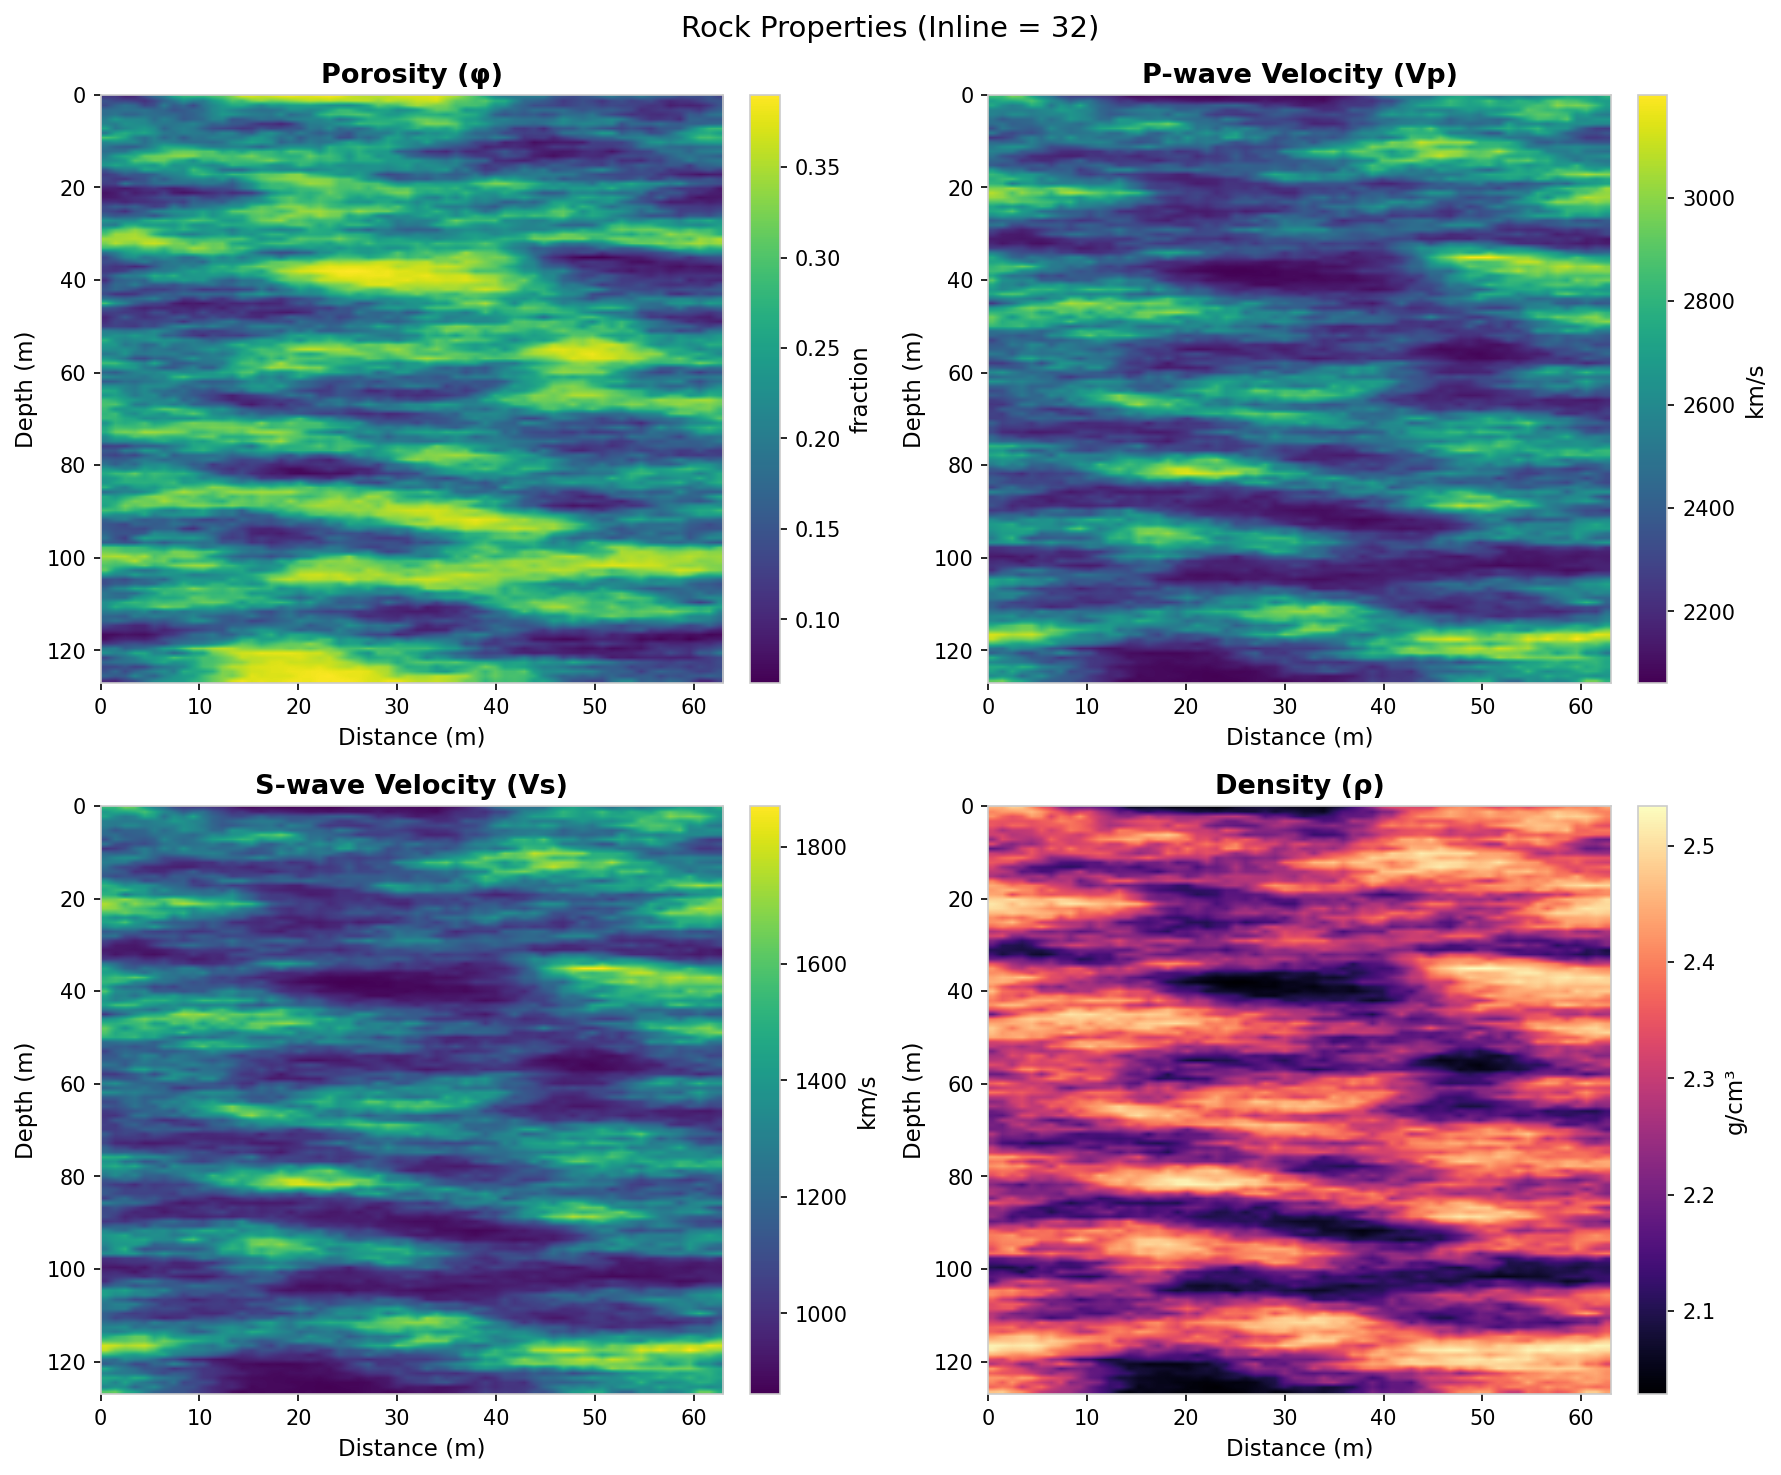

In [6]:
slice_idx = NX // 2

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_field(phi[slice_idx].T, ax=axes[0, 0], cmap='viridis', label='fraction')
axes[0, 0].set_title('Porosity (φ)')

plot_field(vp[slice_idx].T, ax=axes[0, 1], cmap='viridis', label='km/s')
axes[0, 1].set_title('P-wave Velocity (Vp)')

plot_field(vs[slice_idx].T, ax=axes[1, 0], cmap='viridis', label='km/s')
axes[1, 0].set_title('S-wave Velocity (Vs)')

plot_field(rho[slice_idx].T, ax=axes[1, 1], cmap='magma', label='g/cm³')
axes[1, 1].set_title('Density (ρ)')

fig.suptitle(f'Rock Properties (Inline = {slice_idx})', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '06_rock_properties.png'))
plt.show()

## Pre-stack Seismic (Angle Gathers)

The three angle stacks reveal **AVO** (Amplitude Variation with Offset)
effects:

| Angle | Sensitivity |
|-------|-------------|
| **Near** (12°) | Dominated by acoustic-impedance contrast |
| **Mid** (24°) | Contains AVO gradient information |
| **Far** (36°) | Stronger Vs and density influence, lower resolution |

AVO anomalies are key indicators for lithology and fluid identification.

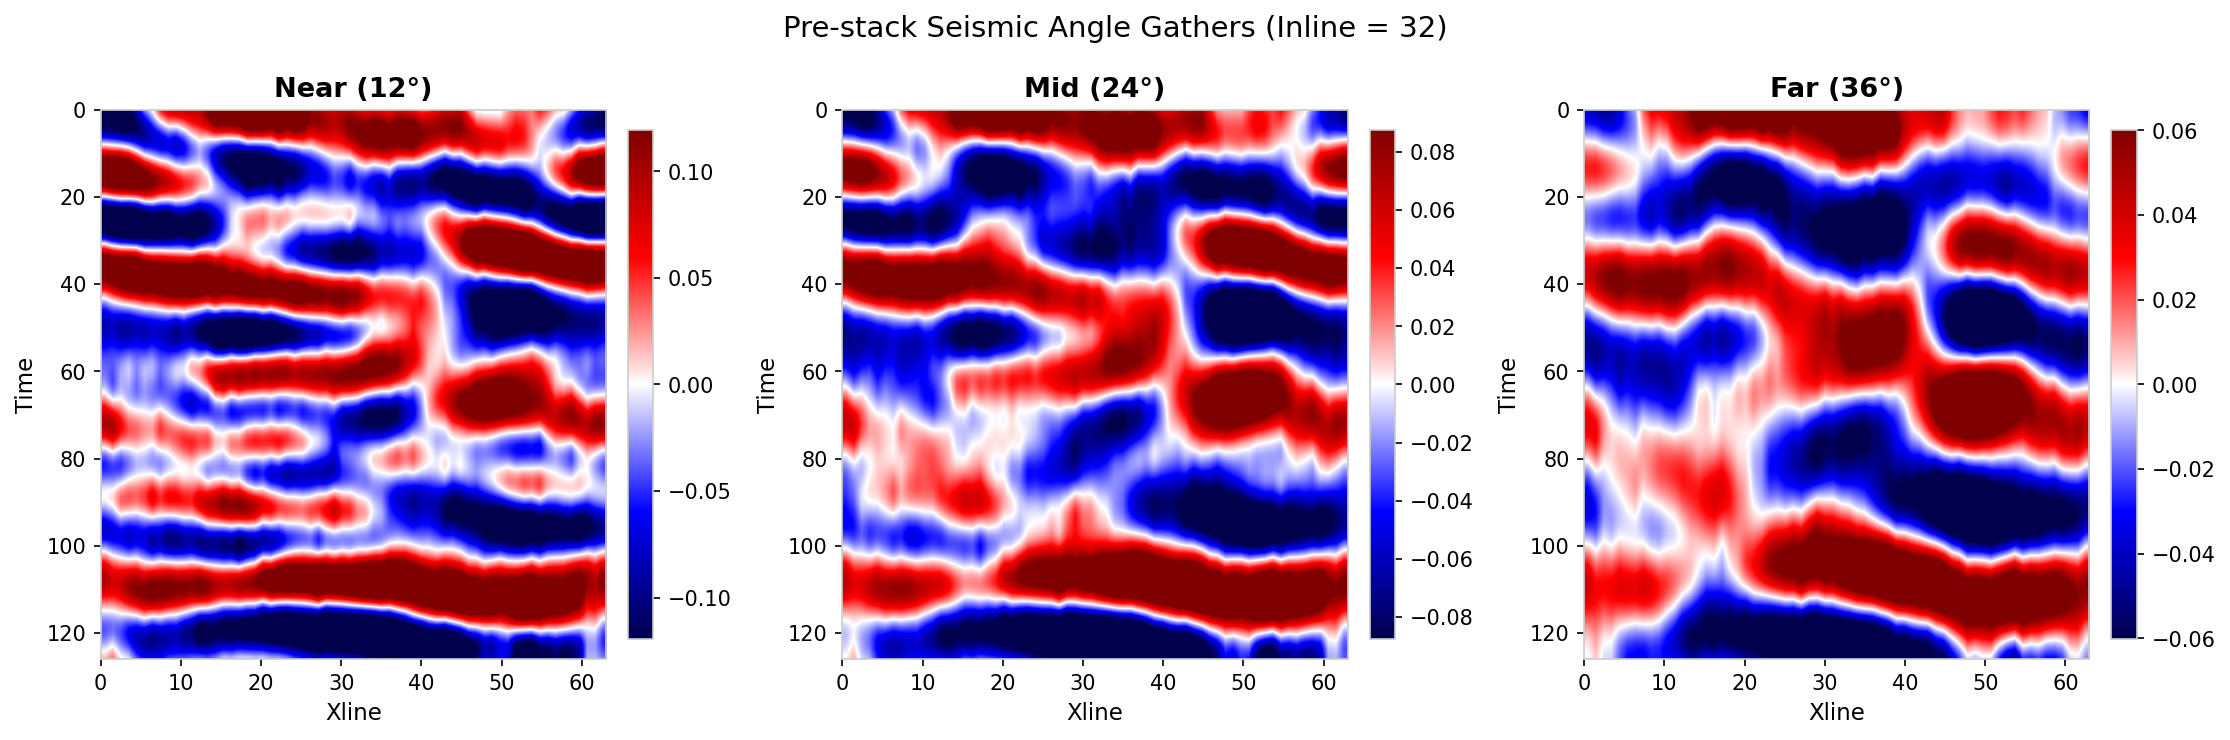

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
plt.subplots_adjust(wspace=0.3)

labels = [f"Near ({THETA_ANGLES[0]}°)", f"Mid ({THETA_ANGLES[1]}°)", f"Far ({THETA_ANGLES[2]}°)"]

for i in range(3):
    plot_section(seismic[i, slice_idx].T, ax=axes[i], clip=80)
    axes[i].set_title(labels[i])
    axes[i].set_xlabel('Xline')
    axes[i].set_ylabel('Time')

fig.suptitle(f'Pre-stack Seismic Angle Gathers (Inline = {slice_idx})', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, '06_angle_gathers.png'))
plt.show()